## HIV 

## Keras Sequential Model Selection

Multilayer Perceptron

Learning Rate	10^-3

Optimizer =Adam

Regularization= L1, L2

Activation= Tanh



In [10]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import SGD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from sklearn.utils import shuffle
from keras import regularizers


#data preperation
df1 = pd.read_csv('/Users/blue/Desktop/HIV/746Data.txt', header=None )
df2 = pd.read_csv('/Users/blue/Desktop/HIV/1625Data.txt', header=None )
df3 = pd.read_csv('/Users/blue/Desktop/HIV/impensData.txt', header=None )
df4 = pd.read_csv('/Users/blue/Desktop/HIV/schillingData.txt', header=None )
frames = [df1, df2, df3, df4] #concatanate all data
HIV = pd.concat(frames).values
dic={'G':1, 'P':2, 'A':3, 'V':4, 'L':5, 'I':6, 'M':7, 'C':8, 'F':9, 
    'Y':10, 'W':11, 'H':12, 'K':13, 'R':14, 'Q':15, 'N':16, 'E':17,'D':18, 'S':19, 'T':20}
octamer= HIV[:,0]
#print(octamer[0][0])
aa_list=[]
for octamer_value in octamer:
    aa_seq=[]
    for aa in octamer_value:
        if(aa in dic.keys()):
            aa_seq.append(dic[aa])
            
    aa_list.append(aa_seq)
    
#print(aa_list)               
x= pd.DataFrame(aa_list).as_matrix()
print(x.shape)
y= HIV[:,1]
y=pd.get_dummies(y).as_matrix()
print(y.shape)


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=100)
    
    
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_val",X_val.shape)
print("y_val",y_val.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)
print("Train/ Validation/ Test = ")

(6590, 8)
(6590, 2)
('X_train', (4217, 8))
('y_train', (4217, 2))
('X_val', (1055, 8))
('y_val', (1055, 2))
('X_test', (1318, 8))
('y_test', (1318, 2))
Train/ Validation/ Test = 


## Best Model

Train on 4217 samples, validate on 1055 samples
Epoch 1/100
4217/4217 [==============================] - 1s 132us/step - loss: 1.2899 - acc: 0.5627 - val_loss: 0.8901 - val_acc: 0.6791
Epoch 2/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.7342 - acc: 0.7019 - val_loss: 0.6492 - val_acc: 0.7289
Epoch 3/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.5930 - acc: 0.7442 - val_loss: 0.5660 - val_acc: 0.7588
Epoch 4/100
4217/4217 [==============================] - 0s 57us/step - loss: 0.5353 - acc: 0.7674 - val_loss: 0.5259 - val_acc: 0.7735
Epoch 5/100
4217/4217 [==============================] - 0s 63us/step - loss: 0.5074 - acc: 0.7778 - val_loss: 0.5052 - val_acc: 0.7839
Epoch 6/100
4217/4217 [==============================] - 0s 62us/step - loss: 0.4913 - acc: 0.7861 - val_loss: 0.4924 - val_acc: 0.7905
Epoch 7/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.4804 - acc: 0.7925 - val_loss: 0.4821 - val_acc: 0.7991

4217/4217 [==============================] - 0s 45us/step - loss: 0.3814 - acc: 0.8452 - val_loss: 0.3853 - val_acc: 0.8417
Epoch 61/100
4217/4217 [==============================] - 0s 44us/step - loss: 0.3813 - acc: 0.8442 - val_loss: 0.3846 - val_acc: 0.8403
Epoch 62/100
4217/4217 [==============================] - 0s 45us/step - loss: 0.3799 - acc: 0.8470 - val_loss: 0.3841 - val_acc: 0.8408
Epoch 63/100
4217/4217 [==============================] - 0s 44us/step - loss: 0.3799 - acc: 0.8453 - val_loss: 0.3848 - val_acc: 0.8431
Epoch 64/100
4217/4217 [==============================] - 0s 44us/step - loss: 0.3779 - acc: 0.8455 - val_loss: 0.3833 - val_acc: 0.8422
Epoch 65/100
4217/4217 [==============================] - 0s 44us/step - loss: 0.3795 - acc: 0.8478 - val_loss: 0.3836 - val_acc: 0.8403
Epoch 66/100
4217/4217 [==============================] - 0s 45us/step - loss: 0.3791 - acc: 0.8448 - val_loss: 0.3841 - val_acc: 0.8403
Epoch 67/100
4217/4217 [==============================

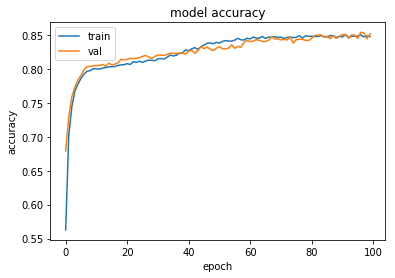

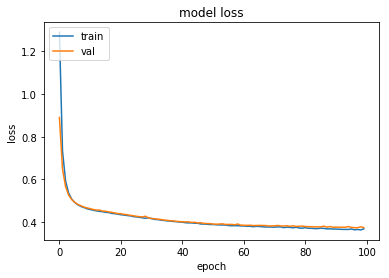

In [11]:
model = Sequential()
model.add(Dense(13, activation='relu', input_dim=8, ))
model.add(Dense(13, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

#compile, configures the model for training.

model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=100,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model

scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model

scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# evaluate the model

scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Model 1

Train on 4217 samples, validate on 1055 samples
Epoch 1/100
4217/4217 [==============================] - 1s 122us/step - loss: 1.9124 - acc: 0.4522 - val_loss: 1.1197 - val_acc: 0.5678
Epoch 2/100
4217/4217 [==============================] - 0s 53us/step - loss: 0.9878 - acc: 0.6368 - val_loss: 0.8104 - val_acc: 0.6896
Epoch 3/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.7997 - acc: 0.7046 - val_loss: 0.6914 - val_acc: 0.7237
Epoch 4/100
4217/4217 [==============================] - 0s 55us/step - loss: 0.6872 - acc: 0.7297 - val_loss: 0.6140 - val_acc: 0.7251
Epoch 5/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.6136 - acc: 0.7401 - val_loss: 0.5631 - val_acc: 0.7483
Epoch 6/100
4217/4217 [==============================] - 0s 56us/step - loss: 0.5687 - acc: 0.7591 - val_loss: 0.5336 - val_acc: 0.7592
Epoch 7/100
4217/4217 [==============================] - 0s 55us/step - loss: 0.5410 - acc: 0.7646 - val_loss: 0.5146 - val_acc: 0.7730

4217/4217 [==============================] - 0s 58us/step - loss: 0.4384 - acc: 0.8001 - val_loss: 0.4433 - val_acc: 0.8076
Epoch 61/100
4217/4217 [==============================] - 0s 51us/step - loss: 0.4377 - acc: 0.8007 - val_loss: 0.4426 - val_acc: 0.8114
Epoch 62/100
4217/4217 [==============================] - 0s 53us/step - loss: 0.4375 - acc: 0.8008 - val_loss: 0.4420 - val_acc: 0.8095
Epoch 63/100
4217/4217 [==============================] - 0s 53us/step - loss: 0.4369 - acc: 0.7997 - val_loss: 0.4410 - val_acc: 0.8090
Epoch 64/100
4217/4217 [==============================] - 0s 52us/step - loss: 0.4365 - acc: 0.8025 - val_loss: 0.4413 - val_acc: 0.8062
Epoch 65/100
4217/4217 [==============================] - 0s 54us/step - loss: 0.4359 - acc: 0.8010 - val_loss: 0.4406 - val_acc: 0.8066
Epoch 66/100
4217/4217 [==============================] - 0s 54us/step - loss: 0.4358 - acc: 0.8031 - val_loss: 0.4417 - val_acc: 0.8052
Epoch 67/100
4217/4217 [==============================

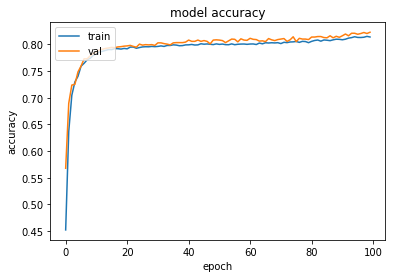

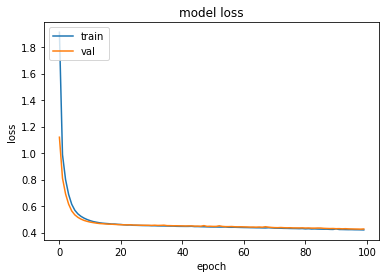

In [9]:
model = Sequential()
model.add(Dense(7, activation='relu', input_dim=8, ))
model.add(Dense(7, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

#compile, configures the model for training.


model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=100,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model

scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model

scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model

scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Model 3

## Model 4